# Compile and Visualize Trust Results

This notebook compiles completed trust-study batch outputs into one formatted CSV and visualizes the distributions of survey response variables.

In [17]:
from __future__ import annotations

import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = Path.cwd().resolve()
if not (ROOT / "simulate").exists():
    for parent in ROOT.parents:
        if (parent / "simulate").exists():
            ROOT = parent
            break

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from simulate.survey import Survey

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 120)

SURVEY_PATH = ROOT / "studies" / "trust" / "survey_trust_new.qsf"
RESULTS_DIR = ROOT / "studies" / "trust" / "results"
OUTPUT_PATH = RESULTS_DIR / "trust_new_compiled_formatted_results.csv"
FIGURES_DIR = RESULTS_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

BLOCKS_TO_SKIP = ["Consent Form", "Filter", "Attention Check"]
RANGE_PATTERN = re.compile(r"trust_new_formatted_results_n(?P<start>\d+)_m(?P<end>\d+)_model(?P<model>.+)_seed(?P<seed>\d+)(?:\.partial)?\.csv$")


## Discover Finished Batches

Final range CSVs in `studies/trust/results/` are preferred. If no final range CSVs exist, the notebook falls back to partial formatted CSVs inside generation folders.

In [18]:
def parse_result_path(path: Path) -> dict:
    match = RANGE_PATTERN.search(path.name)
    if not match:
        return {}
    info = match.groupdict()
    return {
        "participant_start": int(info["start"]),
        "participant_end": int(info["end"]),
        "model_from_filename": info["model"],
        "seed_from_filename": int(info["seed"]),
        "source_file": str(path.relative_to(ROOT)),
    }


def discover_formatted_result_files() -> list[Path]:
    final_files = sorted(
        path
        for path in RESULTS_DIR.glob("trust_new_formatted_results_n*_m*_model*_seed*.csv")
        if ".partial" not in path.name and path.name != OUTPUT_PATH.name
    )
    if final_files:
        return final_files

    return sorted(
        path
        for path in RESULTS_DIR.glob("trust_new_generation_*/trust_new_formatted_results_n*_m*_model*_seed*.partial.csv")
    )


result_files = discover_formatted_result_files()
print(f"Discovered {len(result_files)} formatted result file(s).")
for path in result_files:
    print("-", path.relative_to(ROOT))

if not result_files:
    raise FileNotFoundError(f"No trust formatted result CSVs found under {RESULTS_DIR}")


Discovered 6 formatted result file(s).
- studies/trust/results/trust_new_formatted_results_n0_m30_modelopenai-gpt-4o-mini_seed42.csv
- studies/trust/results/trust_new_formatted_results_n150_m210_modelopenai-gpt-4o-mini_seed42.csv
- studies/trust/results/trust_new_formatted_results_n210_m270_modelopenai-gpt-4o-mini_seed42.csv
- studies/trust/results/trust_new_formatted_results_n270_m390_modelopenai-gpt-4o-mini_seed42.csv
- studies/trust/results/trust_new_formatted_results_n30_m90_modelopenai-gpt-4o-mini_seed42.csv
- studies/trust/results/trust_new_formatted_results_n90_m150_modelopenai-gpt-4o-mini_seed42.csv


## Compile One CSV

In [19]:
frames = []
for path in result_files:
    frame = pd.read_csv(path)
    metadata = parse_result_path(path)
    if metadata:
        metadata_frame = pd.DataFrame({key: [value] * len(frame) for key, value in metadata.items()})
        frame = pd.concat([frame.reset_index(drop=True), metadata_frame], axis=1)
    frames.append(frame)

compiled = pd.concat(frames, ignore_index=True, sort=False)

dedupe_columns = [col for col in ["run_id", "id", "user_system", "user_model"] if col in compiled.columns]
before = len(compiled)
if dedupe_columns:
    compiled = compiled.drop_duplicates(subset=dedupe_columns, keep="last")
else:
    compiled = compiled.drop_duplicates(keep="last")

sort_columns = [col for col in ["participant_start", "sample_index", "id", "user_model", "user_system"] if col in compiled.columns]
if sort_columns:
    compiled = compiled.sort_values(sort_columns).reset_index(drop=True)

compiled.to_csv(OUTPUT_PATH, index=False)
print(f"Rows before dedupe: {before:,}")
print(f"Rows after dedupe:  {len(compiled):,}")
print(f"Columns: {compiled.shape[1]:,}")
print(f"Saved compiled CSV to {OUTPUT_PATH.relative_to(ROOT)}")

compiled.head()


Rows before dedupe: 390
Rows after dedupe:  390
Columns: 157
Saved compiled CSV to studies/trust/results/trust_new_compiled_formatted_results.csv


,run_id,id,user_system,context_mode,user_model,user_temperature,user_max_tokens,belief_pre,gender,year_birth,race,education,education_climate_1,education_climate_2,education_climate_3,income,household,social_class,rural,zip_code,attention1,party,concern_1,concern_2,concern_3,policy_specific_1,policy_specific_2,policy_specific_3,policy_specific_4,policy_specific_5,policy_specific_6,policy_specific_7,religion,inst_trust_epa,inst_trust_nasa,inst_trust_noaa,inst_trust_uni,inst_trust_gov,trust_pre,state,trust_competent,trust_intelligent,trust_qualified,trust_honest,trust_ethical,trust_sincere,trust_concerned,trust_improve,trust_considerate,trust_feedback,trust_transparent,trust_attention,belief_post,trust_post,distrust,policy_1,policy_2,policy_3,policy_4,policy_general,...,partisan_importance,religiosity,religion_bornagain,survey_flow_trace,survey_flow_warnings,survey_embedded_data,survey_embedded_labels,survey_intervention_messages,survey_user_messages,survey_embedded_projectId,survey_embedded_assignmentId,survey_embedded_participantId,survey_embedded_completed_study,survey_embedded_excluded,survey_embedded_condition,survey_embedded_label_condition,profile_id,year,wtssps,age,sex,race_human,hispanic,degree,income16,hompop,class,region,partyid,polviews,relig,reborn,reliten,attend,consci,gss_id,gender_human,education_human,income_level,political_party,party_human,political_orientation,religion_human,ethnicity,bio,country,country_code,source_persona_id,sample_name,sample_index,gender_sim_error,race_sim_error,education_sim_error,party_sim_error,religion_sim_error,participant_start,participant_end,model_from_filename,seed_from_filename,source_file
0,run_f0c78143ed82,full_00001,gss_prompt,none,openai/gpt-4o-mini,1.2,512,85,1,2002,1,2,1,1,2,4,3,2,2,90210,9,2,85,90,80,70,80,90,90,60,85,95,14,75,85,80,78,60,90,NaN,90,85,88,85,80,82,78,75,80,85,88,70,90,90,10,90,70,88,75,85,...,NaN,35.0,2.0,"[{'type': 'embedded_data', 'flow_id': 'FL_3', ...","['Could not evaluate branch FL_6; skipping.', ...","{'projectId': None, 'assignmentId': None, 'par...",{},[],"[{'role': 'system', 'content': ""You are an exp...",NaN,NaN,NaN,1,NaN,orchid orangutan; defiant dragonfly,NaN,p01096,2016,3.688917,24,male,White,not hispanic,high school,"$130,000 to $149,999",3.0,working class,West,"independent, close to republican",slightly liberal,catholic,no,not very strong,never,a great deal,1406,Male,High School,"$130,000 to $149,999","independent, close to republican","independent, close to republican",slightly liberal,catholic,Non-Hispanic,NaN,United States,US,p01096,full,1,NaN,NaN,NaN,NaN,NaN,0,30,openai-gpt-4o-mini,42,studies/trust/results/trust_new_formatted_resu...
1,run_6a49a7a7b710,full_00002,gss_prompt,none,openai/gpt-4o-mini,1.2,512,40,2,1954,1,4,2,2,2,2,2,2,3,12345,9,2,50,70,55,50,55,50,65,40,45,70,14,50,60,55,50,40,20,NaN,40,45,50,30,35,40,45,50,40,50,40,45,40,20,60,70,40,75,60,60,...,NaN,30.0,2.0,"[{'type': 'embedded_data', 'flow_id': 'FL_3', ...","['Could not evaluate branch FL_6; skipping.', ...","{'projectId': None, 'assignmentId': None, 'par...",{},[],"[{'role': 'system', 'content': ""You are an exp...",NaN,NaN,NaN,1,NaN,worse wildfowl,NaN,p07007,2022,0.431823,72,female,White,not hispanic,bachelor's,"$40,000 to $49,999",2.0,working class,South,"independent, close to republican",conservative,catholic,no,NaN,about once or twice a year,hardly any,2277,Female,Bachelor's,"$40,000 to $49,999","independent, close to republican","independent, close to republican",conservative,catholic,Non-Hispanic,NaN,United States,US,p07007,full,2,NaN,NaN,NaN,NaN,NaN,0,30,openai-gpt-4o-mini,42,studies/trust/results/trust_new_formatted_resu...
2,run_649d9fdefcd0,full_00003,gss_prompt,none,openai/gpt-4o-mini,1.2,512,50,2,1937,2,3,2,2,2,0,2,3,3,45678,9,3,70,75,65,40,50,55,60,30,40,45,16,30,25,30,20,15,20,NaN,30,25,25,20,15,20,30,25,35,25,20,30,40,15,85,40,35,50,45,35,...,75.0,85.0,1.0,"[{'type': 'embedded_data', 'flow_id': 'FL_3', ...","['Could not evaluate branch FL_6; skipping.', 

## Batch Coverage

In [20]:
coverage_cols = [col for col in ["participant_start", "participant_end", "user_model", "source_file"] if col in compiled.columns]
if coverage_cols:
    batch_coverage = (
        compiled.groupby(coverage_cols, dropna=False)
        .size()
        .reset_index(name="rows")
        .sort_values([col for col in ["participant_start", "participant_end", "user_model"] if col in coverage_cols])
    )
    display(batch_coverage)

summary_cols = [col for col in ["user_model", "user_system", "survey_embedded_condition", "survey_embedded_label_condition"] if col in compiled.columns]
if summary_cols:
    condition_summary = (
        compiled.groupby(summary_cols, dropna=False)
        .size()
        .reset_index(name="rows")
        .sort_values("rows", ascending=False)
    )
    display(condition_summary.head(40))


,participant_start,participant_end,user_model,source_file,rows
0,0,30,openai/gpt-4o-mini,studies/trust/results/trust_new_formatted_resu...,30
1,30,90,openai/gpt-4o-mini,studies/trust/results/trust_new_formatted_resu...,60
2,90,150,openai/gpt-4o-mini,studies/trust/results/trust_new_formatted_resu...,60
3,150,210,openai/gpt-4o-mini,studies/trust/results/trust_new_formatted_resu...,60
4,210,270,openai/gpt-4o-mini,studies/trust/results/trust_new_formatted_resu...,60
5,270,390,openai/gpt-4o-mini,studies/trust/results/trust_new_formatted_resu...,120


,user_model,user_system,survey_embedded_condition,survey_embedded_label_condition,rows
11,openai/gpt-4o-mini,gss_prompt,giant gibbon; brick bobcat,NaN,22
9,openai/gpt-4o-mini,gss_prompt,difficult dog,NaN,22
20,openai/gpt-4o-mini,gss_prompt,practical planarian,NaN,22
18,openai/gpt-4o-mini,gss_prompt,periwinkle partridge,NaN,22
17,openai/gpt-4o-mini,gss_prompt,perfect prawn,NaN,22
15,openai/gpt-4o-mini,gss_prompt,limping llama; friendly frog,NaN,22
14,openai/gpt-4o-mini,gss_prompt,jealous jaguar,NaN,22
12,openai/gpt-4o-mini,gss_prompt,heartfelt hummingbird,NaN,22
1,openai/gpt-4o-mini,gss_prompt,complicated cockroach,NaN,22
21,openai/gpt-4o-mini,gss_prompt,worse wildfowl,NaN,22


## Identify Response Variables

Response variables are derived from the parsed QSF scale item keys. Metadata columns, simulator transcript columns, and human/source-persona columns are left out of the distribution plots.

In [21]:
survey = Survey(str(SURVEY_PATH))
survey.set_excluded_blocks(BLOCKS_TO_SKIP)

scale_items = []
for scale_name in survey.get_scales(None):
    scale = survey.scales[scale_name]
    for item_key in scale["items"]:
        if item_key in compiled.columns:
            scale_items.append(
                {
                    "scale": scale_name,
                    "variable": item_key,
                    "type": scale.get("type"),
                    "n_non_null": int(compiled[item_key].notna().sum()),
                    "n_unique": int(compiled[item_key].nunique(dropna=True)),
                }
            )

response_catalog = pd.DataFrame(scale_items)
response_columns = response_catalog["variable"].tolist()

print(f"Response variables found: {len(response_columns)}")
display(response_catalog)


Response variables found: 93


,scale,variable,type,n_non_null,n_unique
0,belief_pre,belief_pre,numeric,390,17
1,gender,gender,multiple choice,390,2
2,year_birth,year_birth,free text,390,68
3,race,race,multiple choice,390,4
4,education,education,multiple choice,390,5
...,...,...,...,...,...
88,individual_talk,individual_talk,numeric,390,17
89,individual_donate,individual_donate,numeric,390,18
90,partisan_importance,partisan_importance,numeric,182,13
91,religiosity,religiosity,numeric,294,15


## Numeric Response Distributions

Numeric response variables: 78
Categorical/free-text response variables: 15
Saved studies/trust/results/figures/trust_numeric_response_distributions_page_01.png


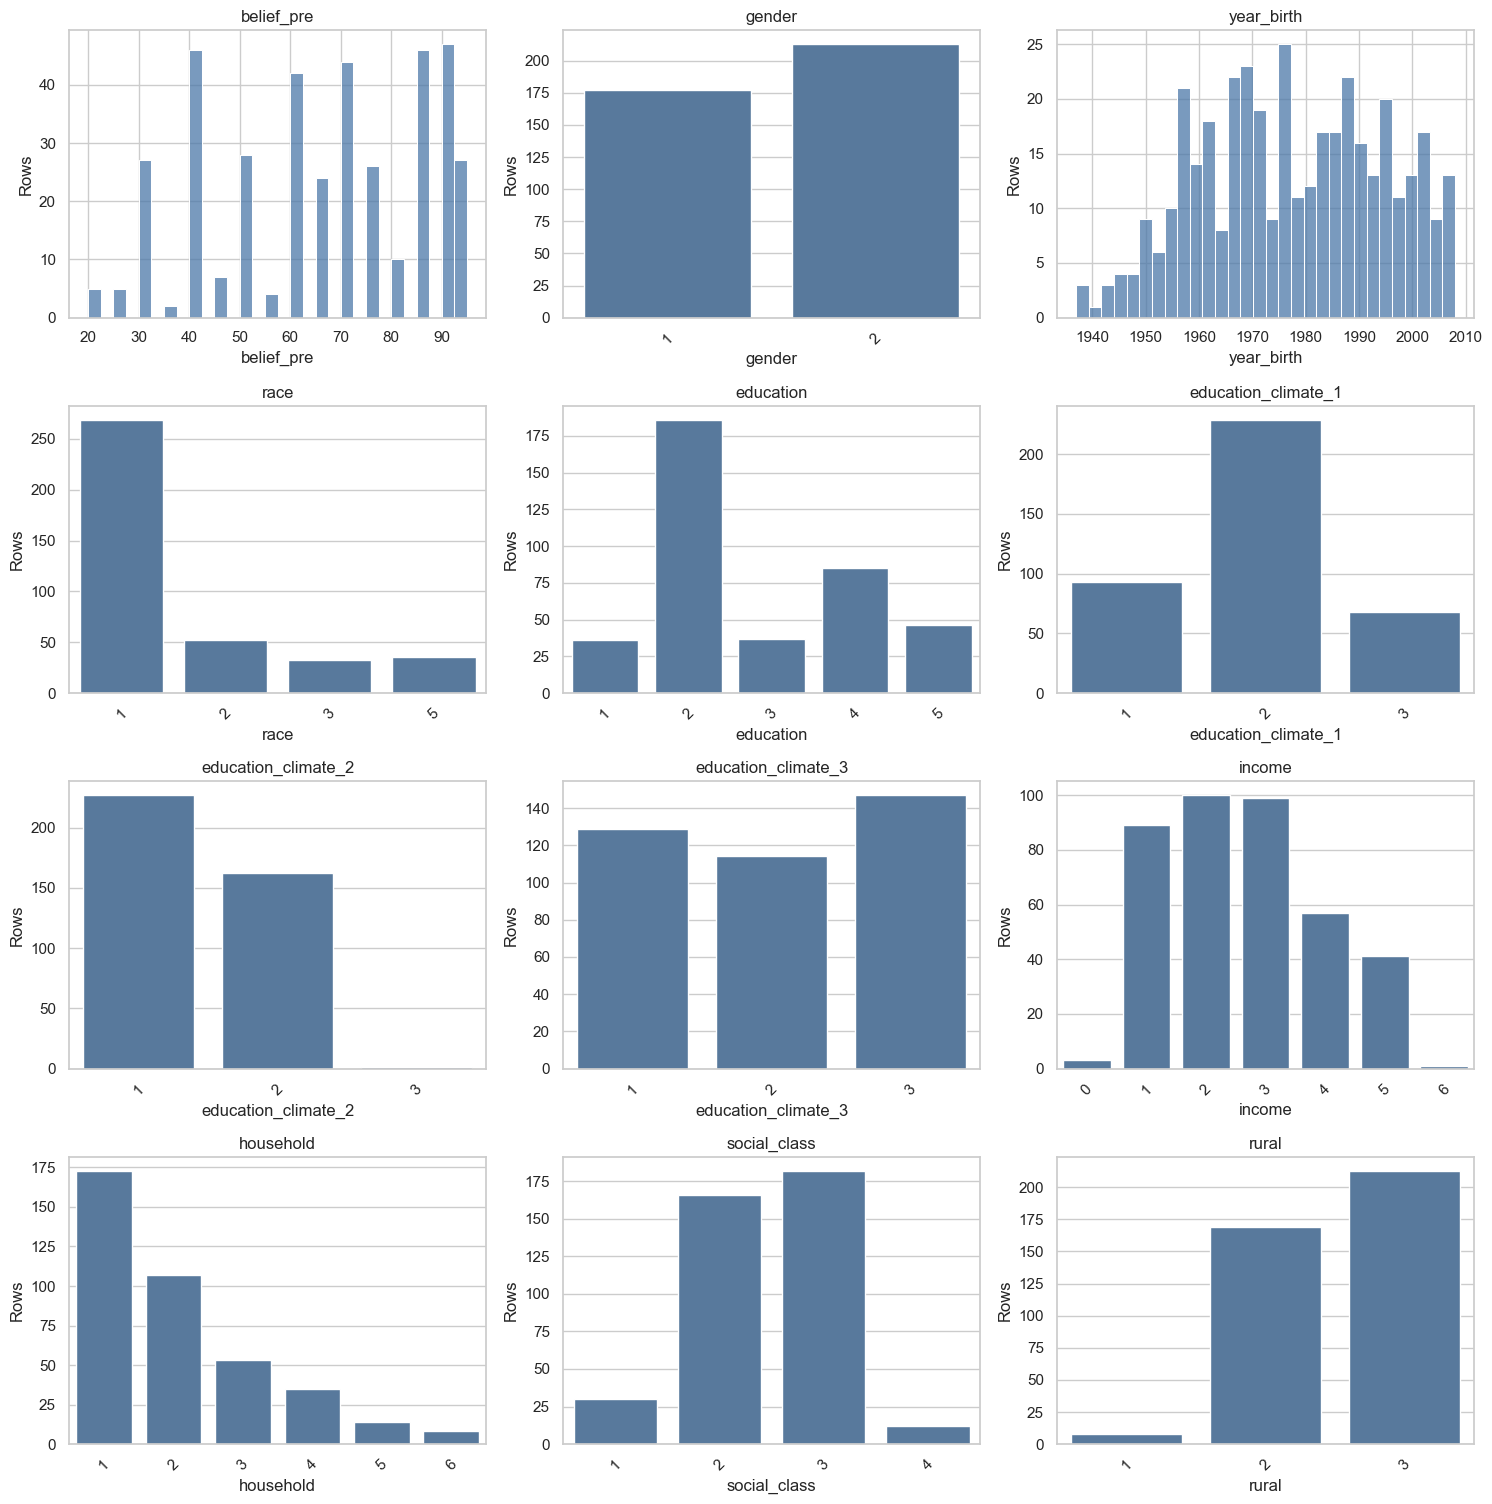

Saved studies/trust/results/figures/trust_numeric_response_distributions_page_02.png


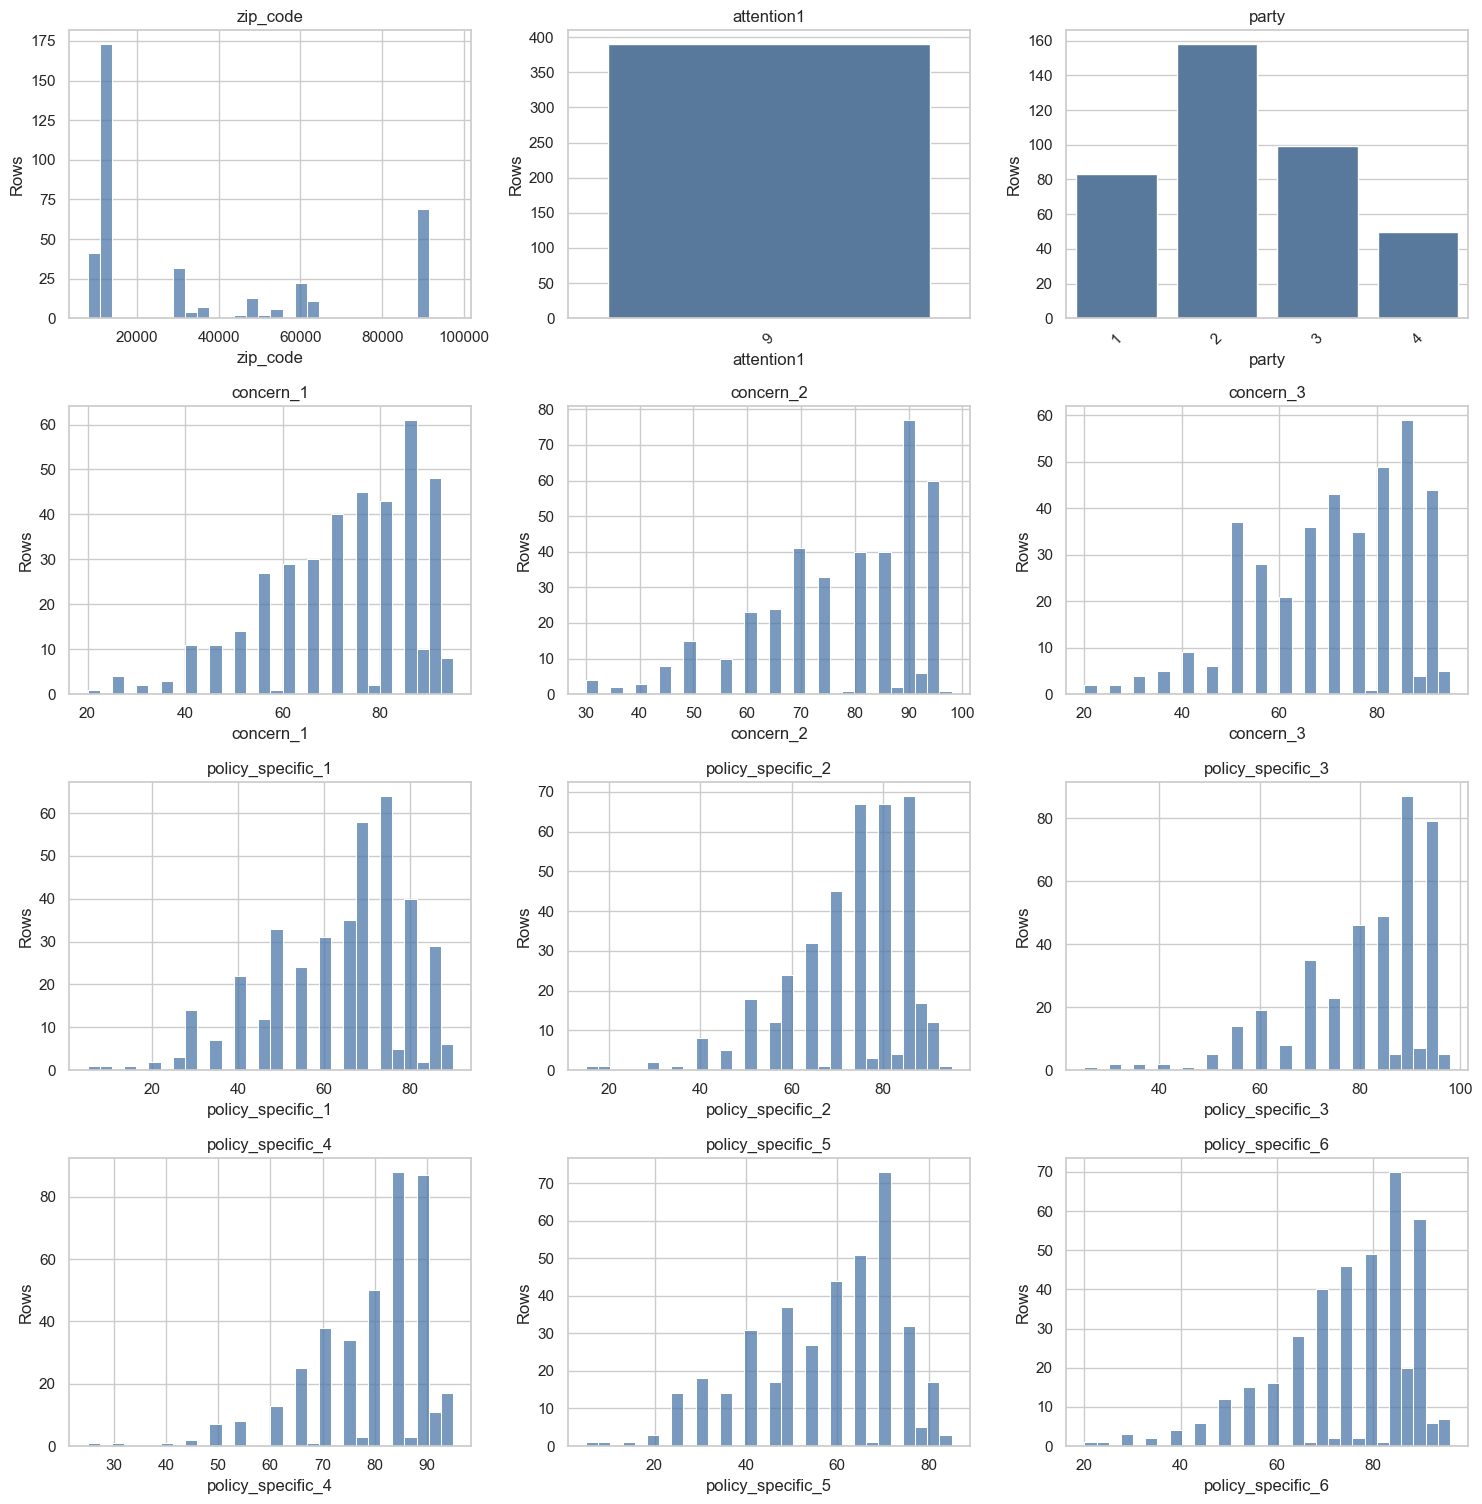

Saved studies/trust/results/figures/trust_numeric_response_distributions_page_03.png


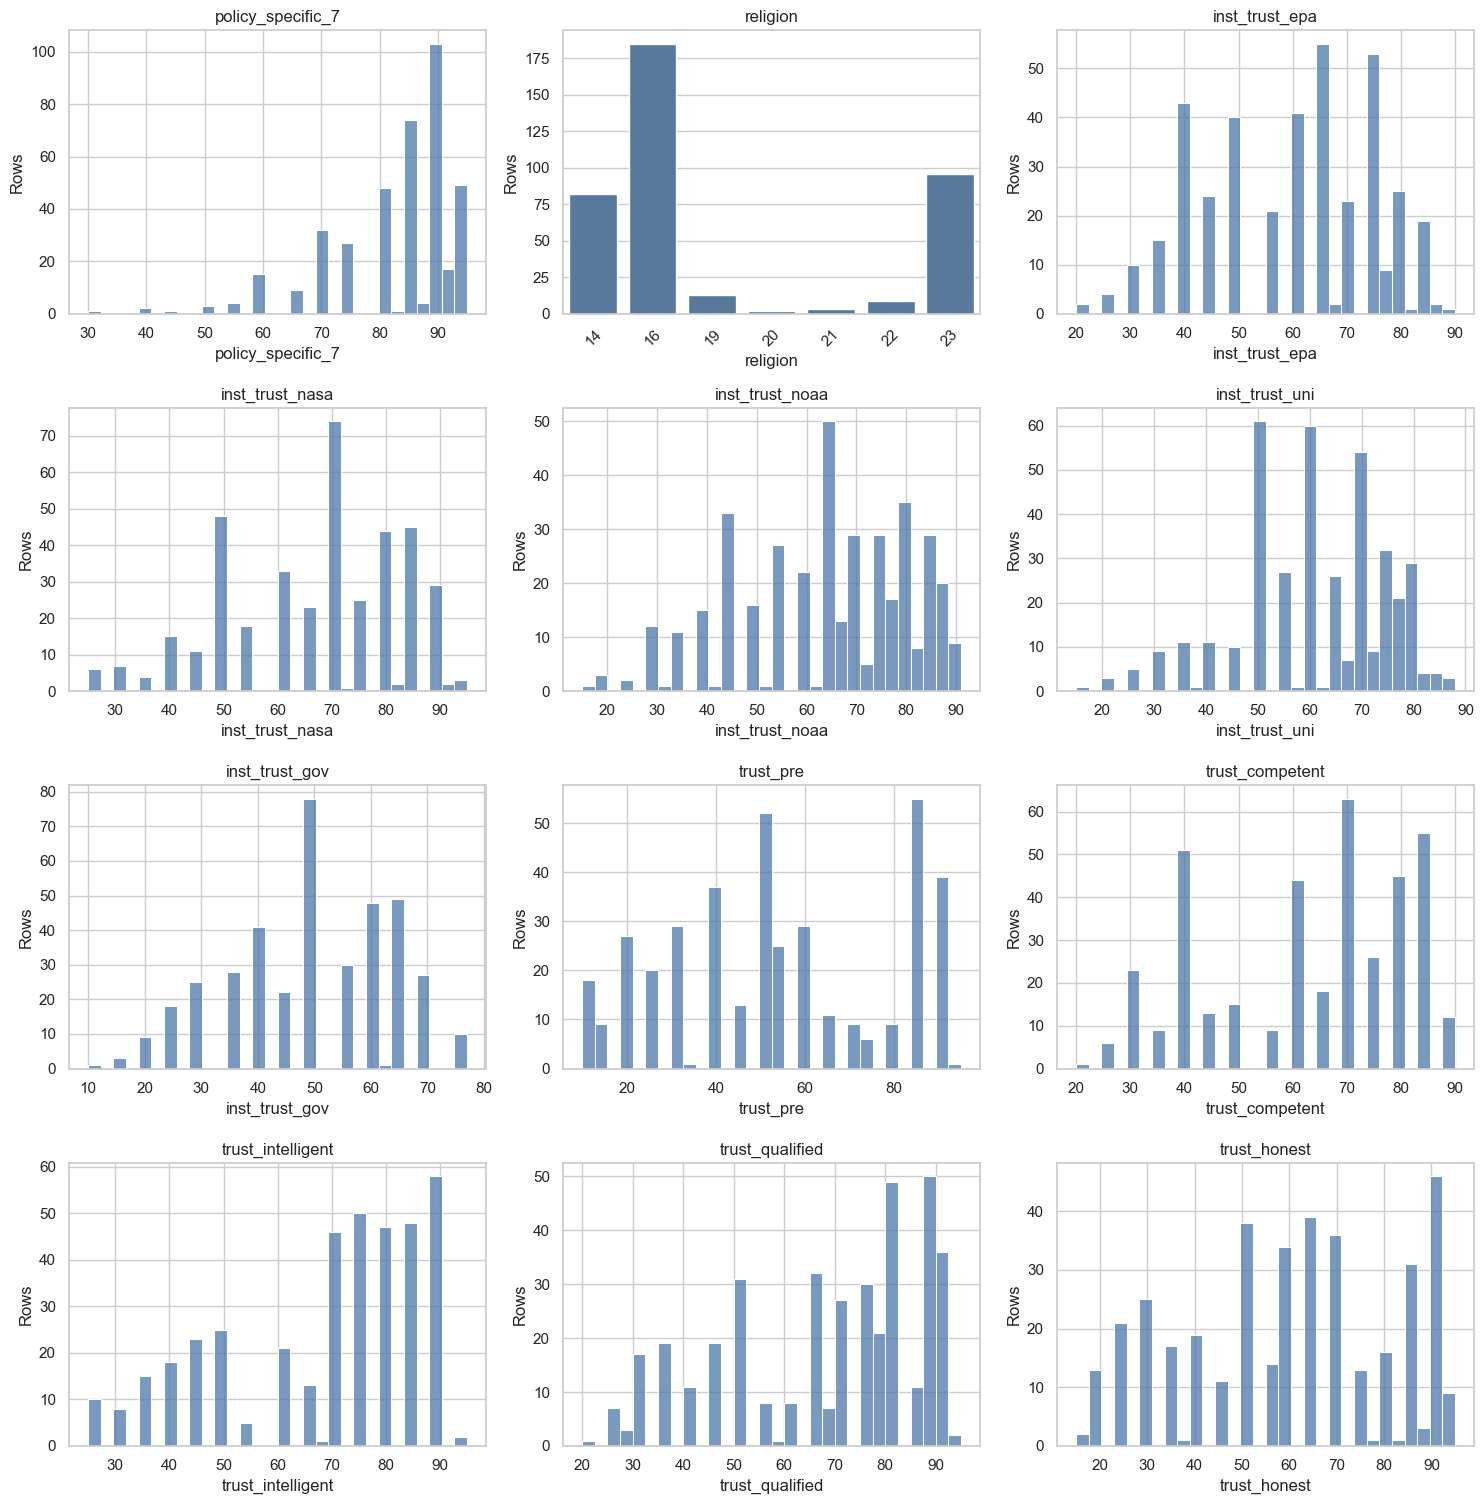

Saved studies/trust/results/figures/trust_numeric_response_distributions_page_04.png


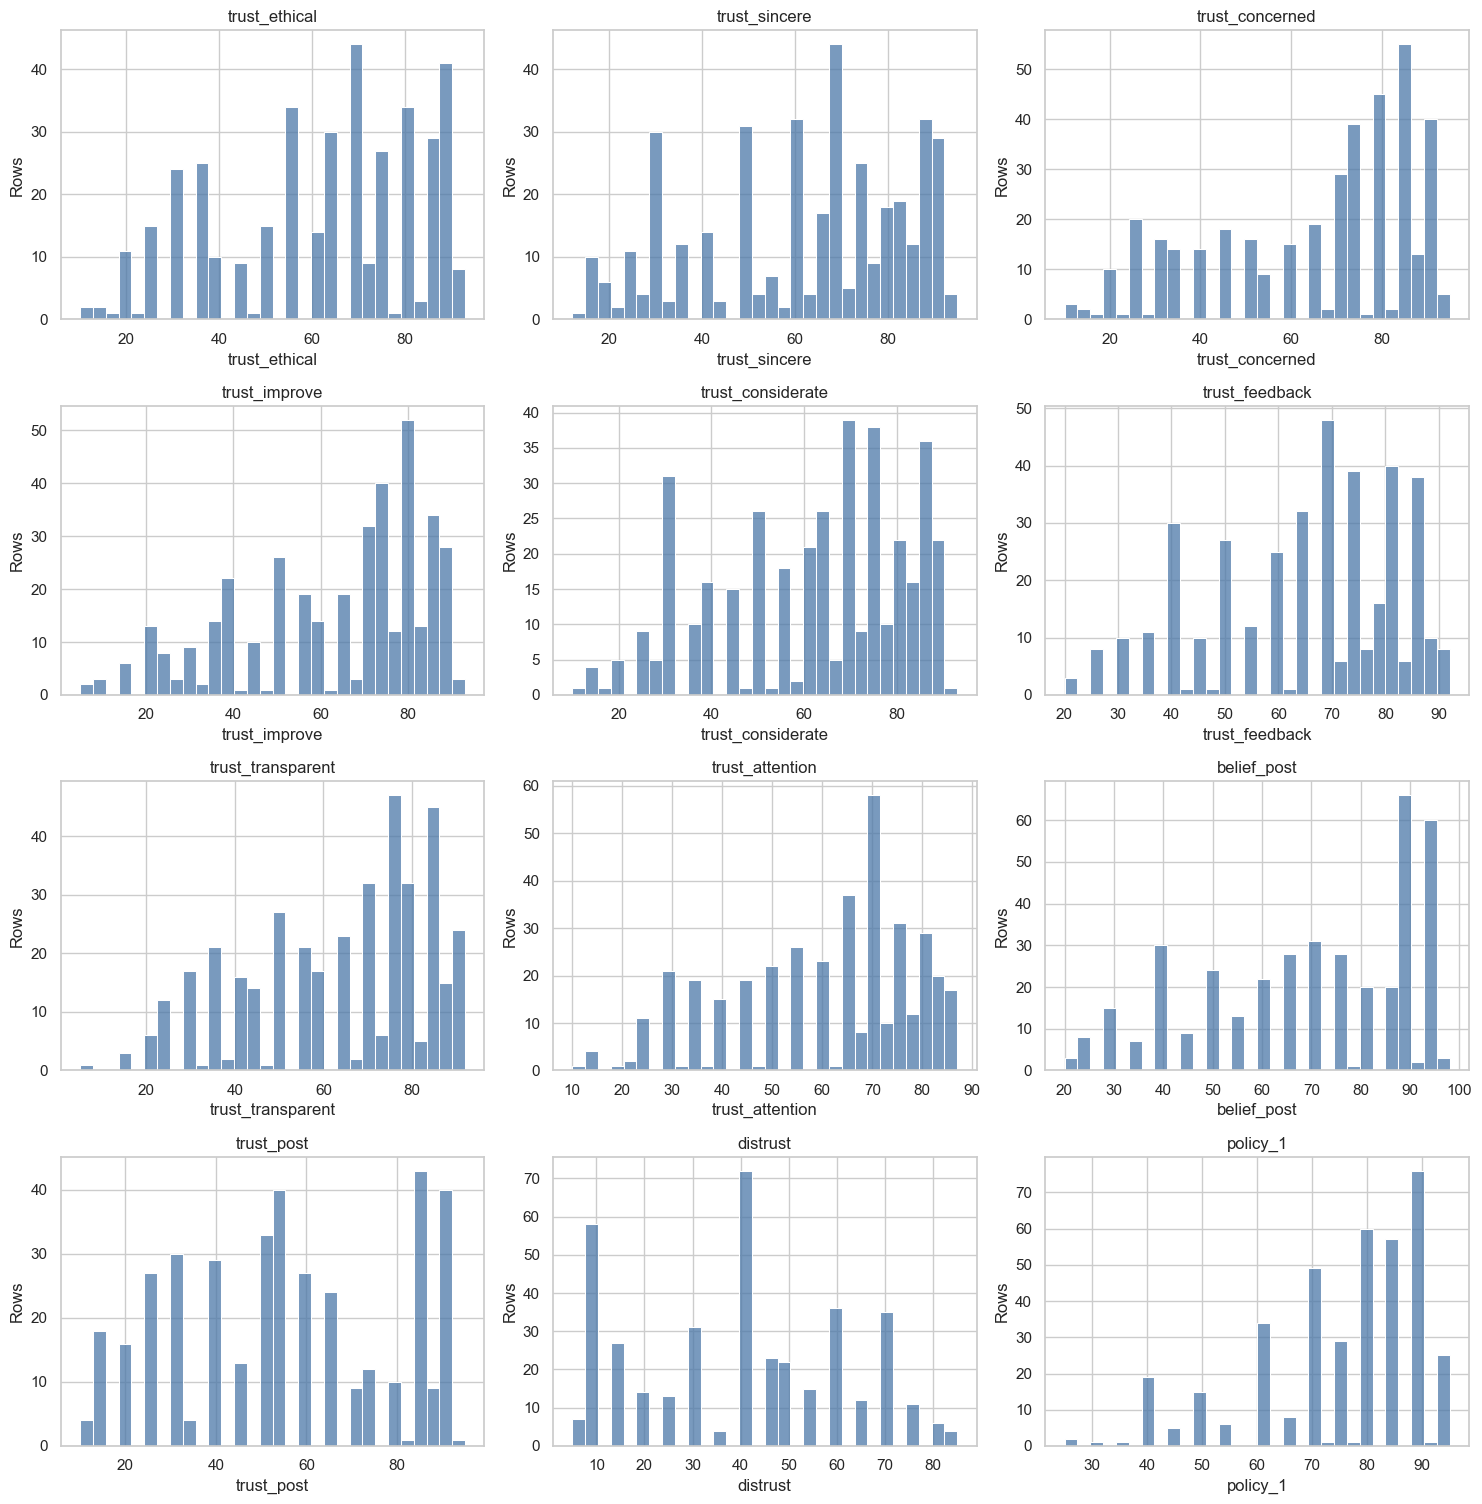

Saved studies/trust/results/figures/trust_numeric_response_distributions_page_05.png


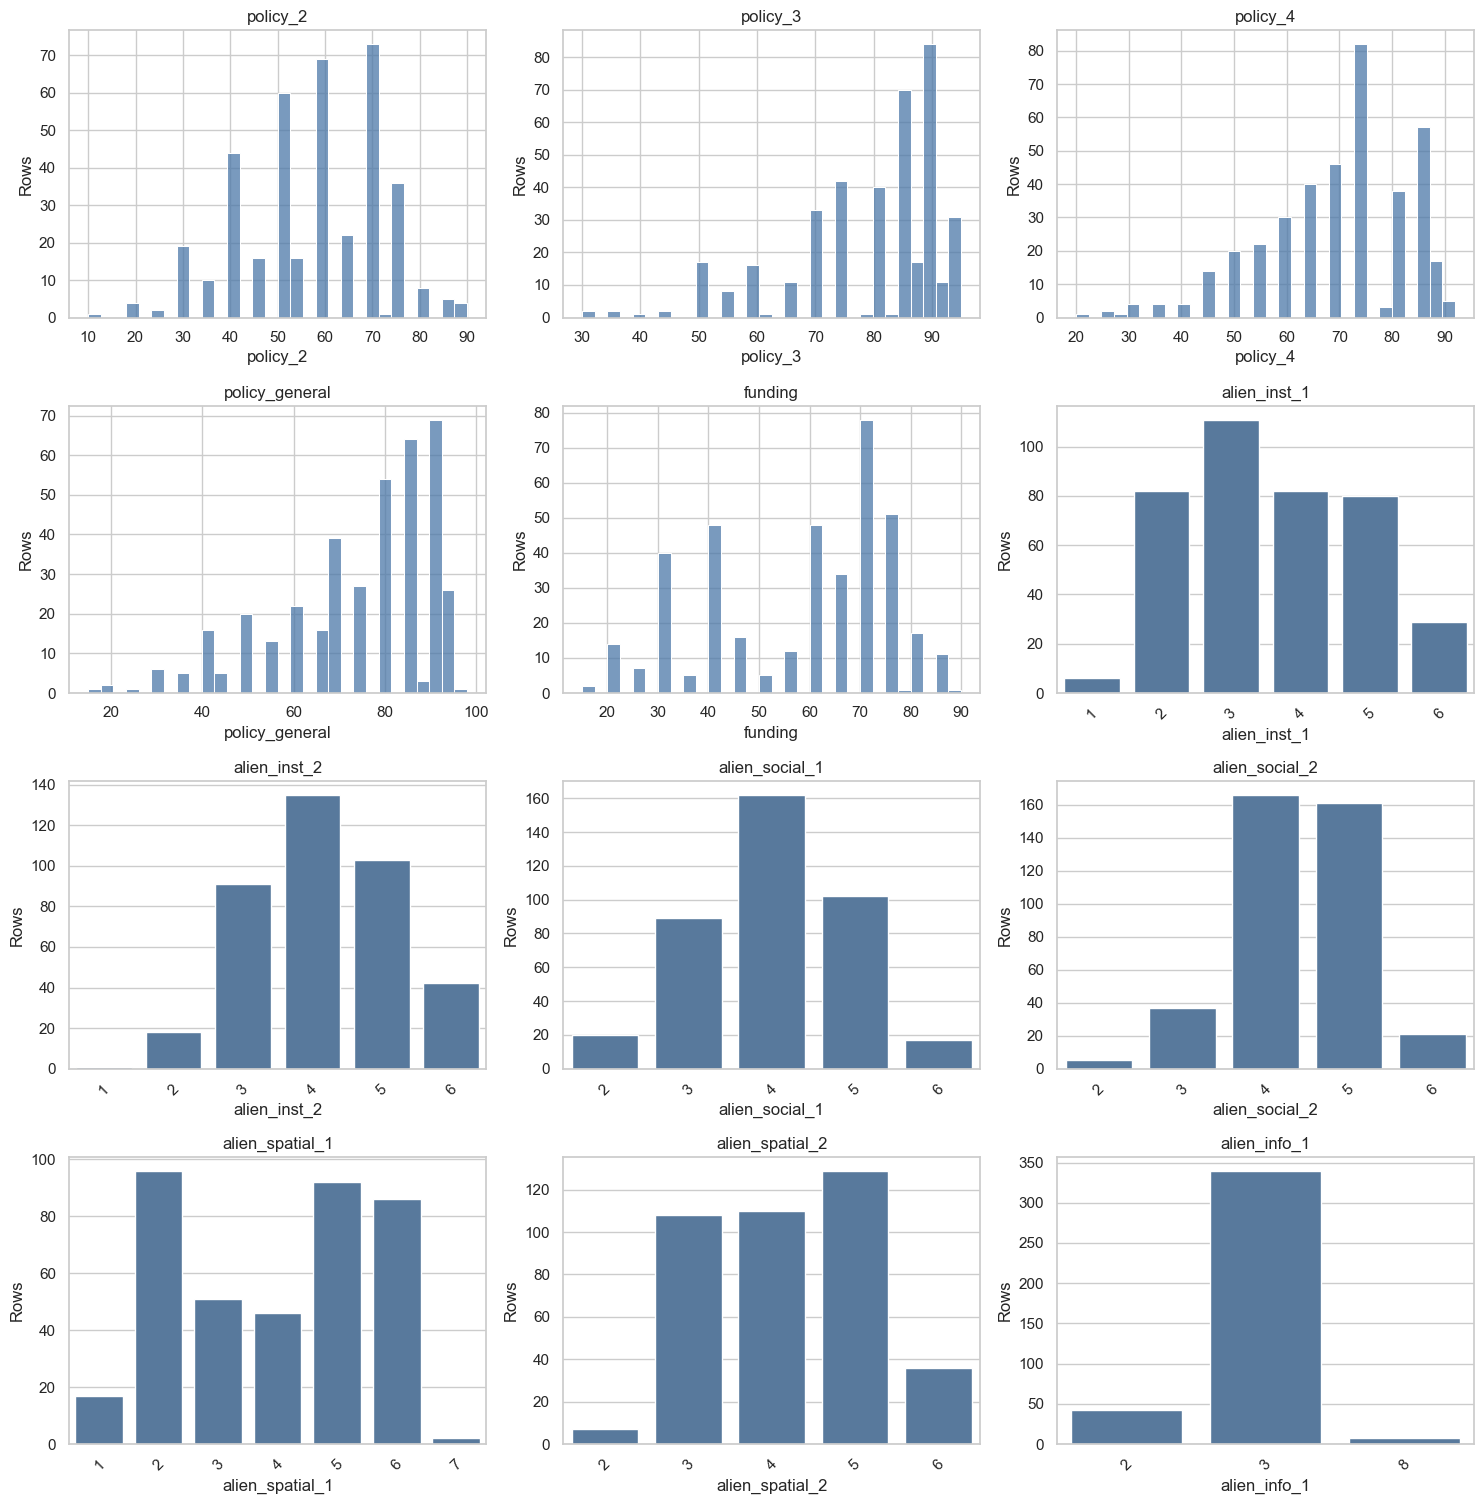

Saved studies/trust/results/figures/trust_numeric_response_distributions_page_06.png


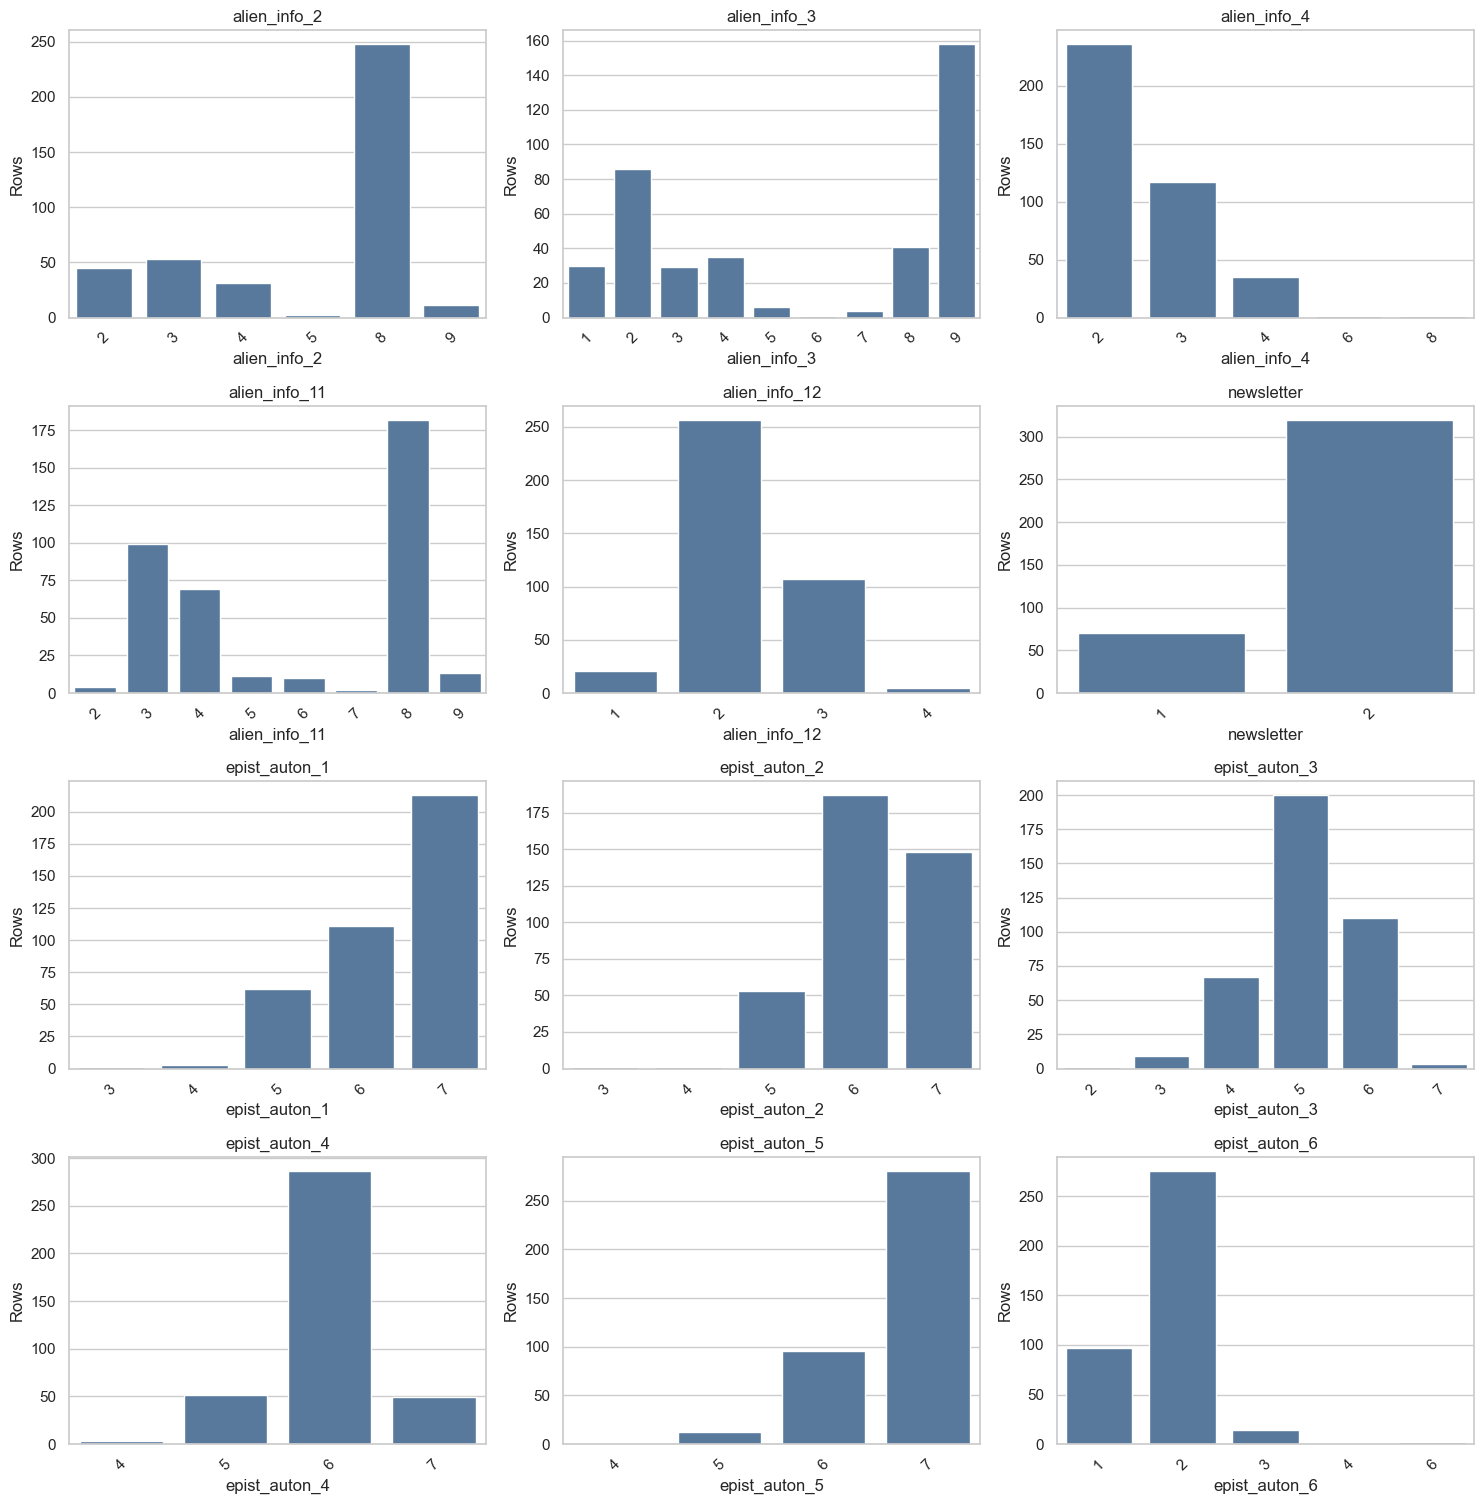

Saved studies/trust/results/figures/trust_numeric_response_distributions_page_07.png


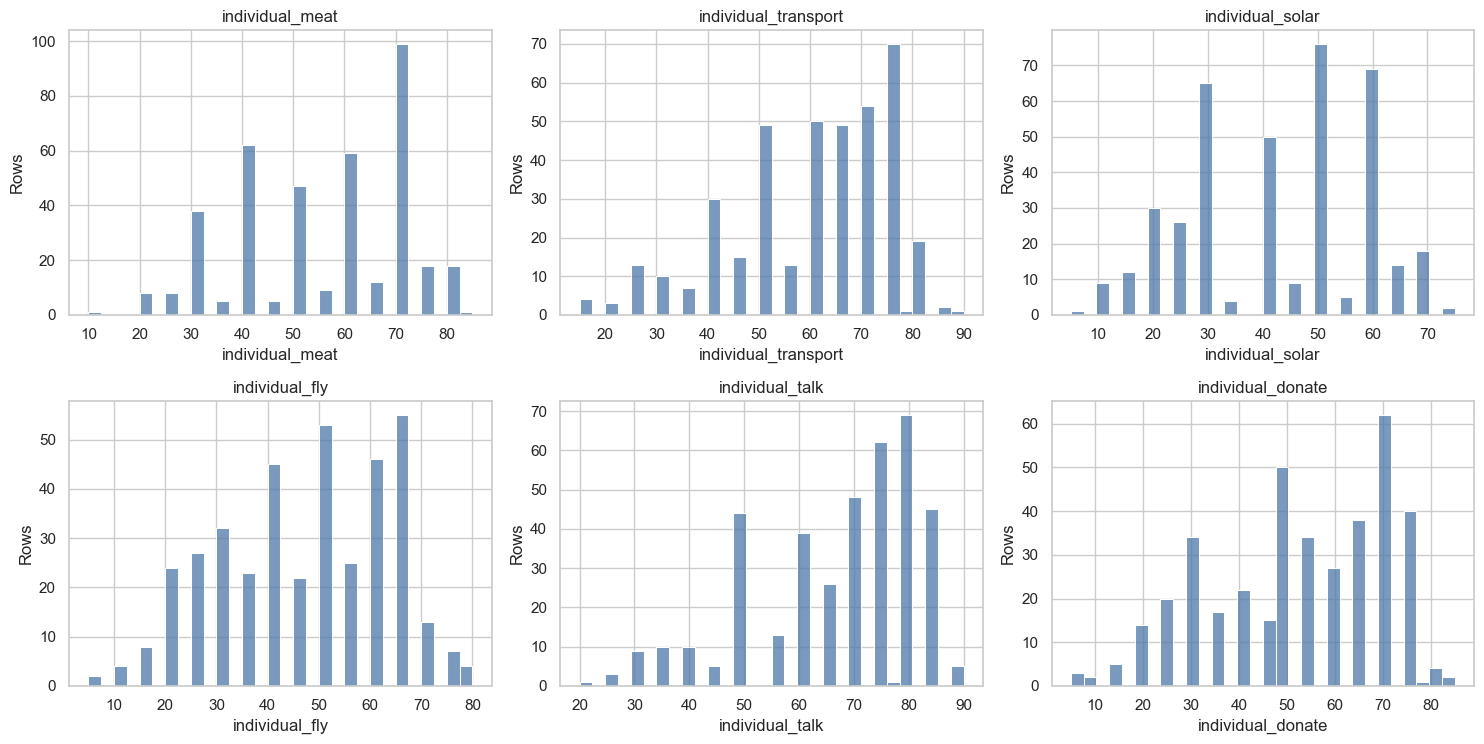

In [22]:
numeric_response_columns = []
categorical_response_columns = []

for column in response_columns:
    numeric_values = pd.to_numeric(compiled[column], errors="coerce")
    numeric_share = numeric_values.notna().mean()
    if numeric_share >= 0.8 and numeric_values.notna().sum() > 0:
        compiled[column] = numeric_values
        numeric_response_columns.append(column)
    else:
        categorical_response_columns.append(column)

print(f"Numeric response variables: {len(numeric_response_columns)}")
print(f"Categorical/free-text response variables: {len(categorical_response_columns)}")

def plot_numeric_grid(columns: list[str], *, columns_per_page: int = 12) -> None:
    if not columns:
        print("No numeric response variables to plot.")
        return

    for page_start in range(0, len(columns), columns_per_page):
        page_columns = columns[page_start : page_start + columns_per_page]
        ncols = 3
        nrows = int(np.ceil(len(page_columns) / ncols))
        fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3.8 * nrows), squeeze=False)
        axes_flat = axes.ravel()

        for axis, column in zip(axes_flat, page_columns):
            values = compiled[column].dropna()
            unique_count = values.nunique()
            if unique_count <= 12:
                order = sorted(values.unique())
                sns.countplot(x=values, order=order, ax=axis, color="#4C78A8")
                axis.set_xlabel(column)
                axis.tick_params(axis="x", labelrotation=45)
            else:
                sns.histplot(values, bins=30, kde=False, ax=axis, color="#4C78A8")
                axis.set_xlabel(column)
            axis.set_ylabel("Rows")
            axis.set_title(column)

        for axis in axes_flat[len(page_columns) :]:
            axis.set_visible(False)

        fig.tight_layout()
        figure_path = FIGURES_DIR / f"trust_numeric_response_distributions_page_{page_start // columns_per_page + 1:02d}.png"
        fig.savefig(figure_path, dpi=180, bbox_inches="tight")
        print(f"Saved {figure_path.relative_to(ROOT)}")
        plt.show()


plot_numeric_grid(numeric_response_columns)


## Categorical and Free-Text Response Distributions

Saved studies/trust/results/figures/trust_categorical_response_distributions_page_01.png


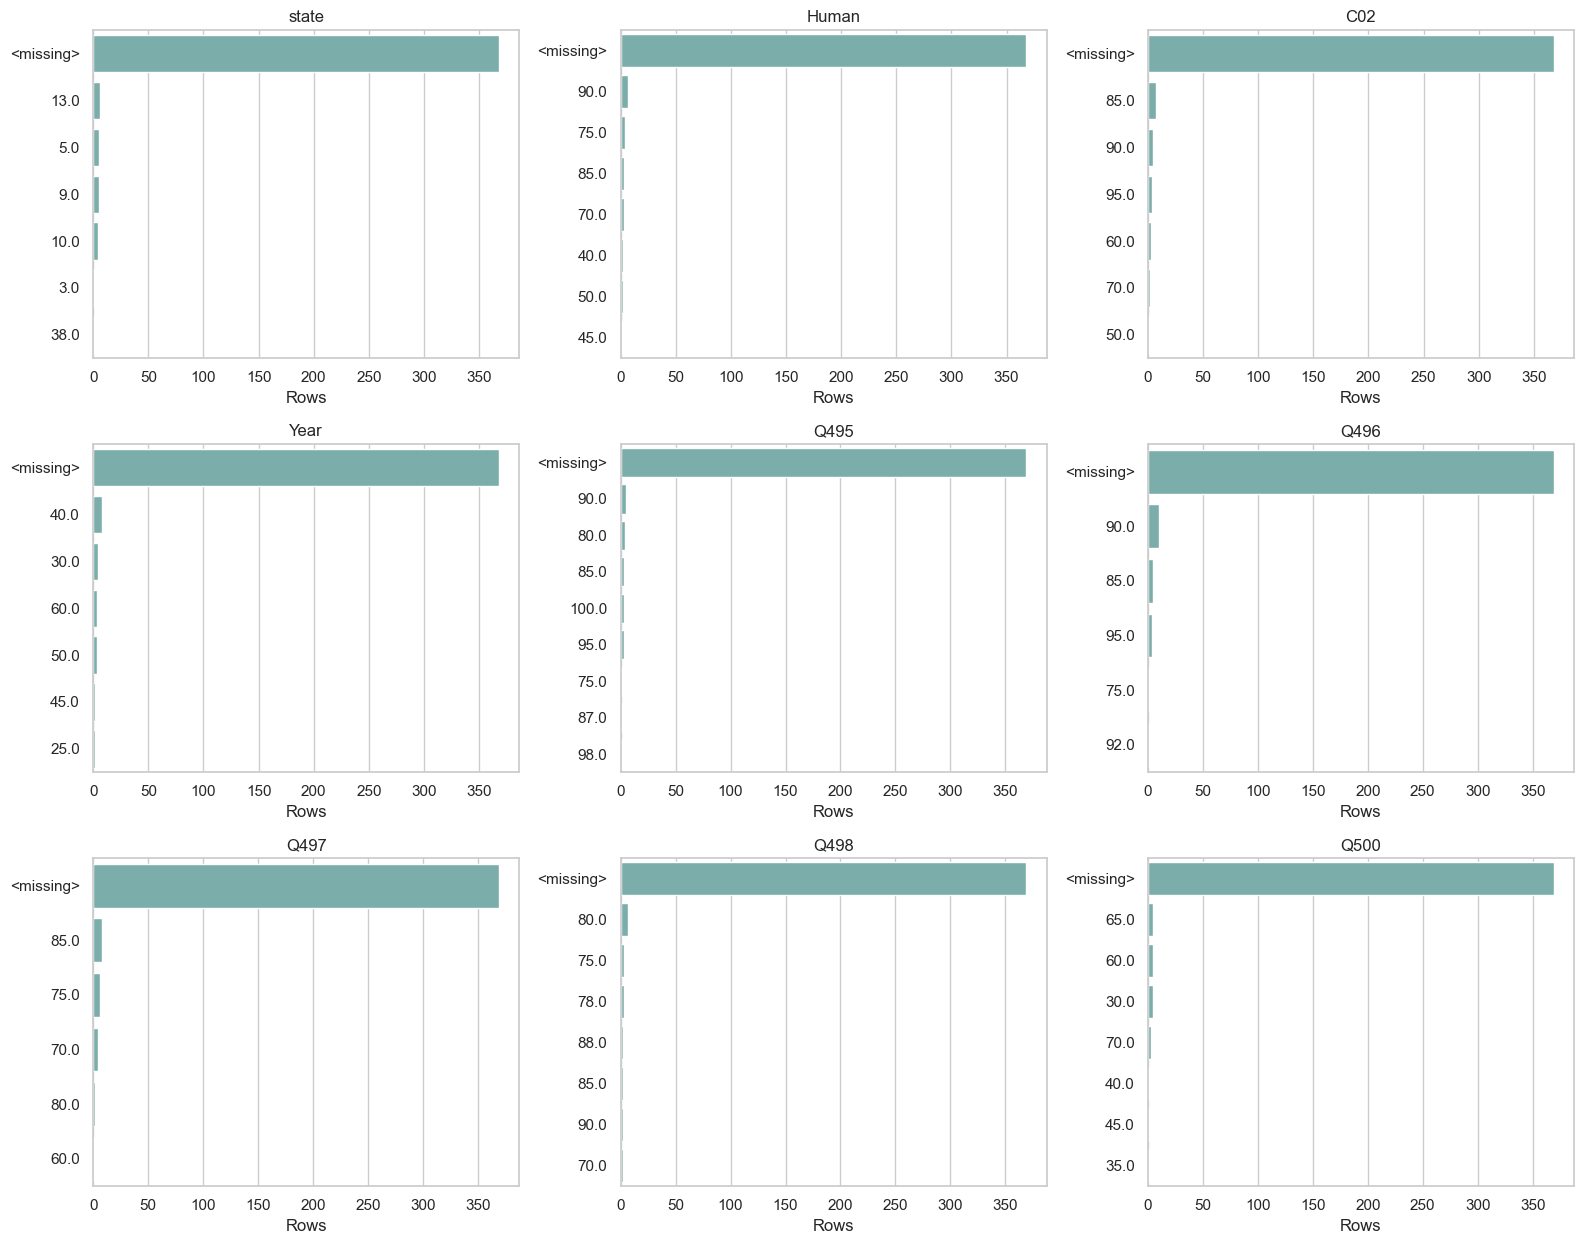

Saved studies/trust/results/figures/trust_categorical_response_distributions_page_02.png


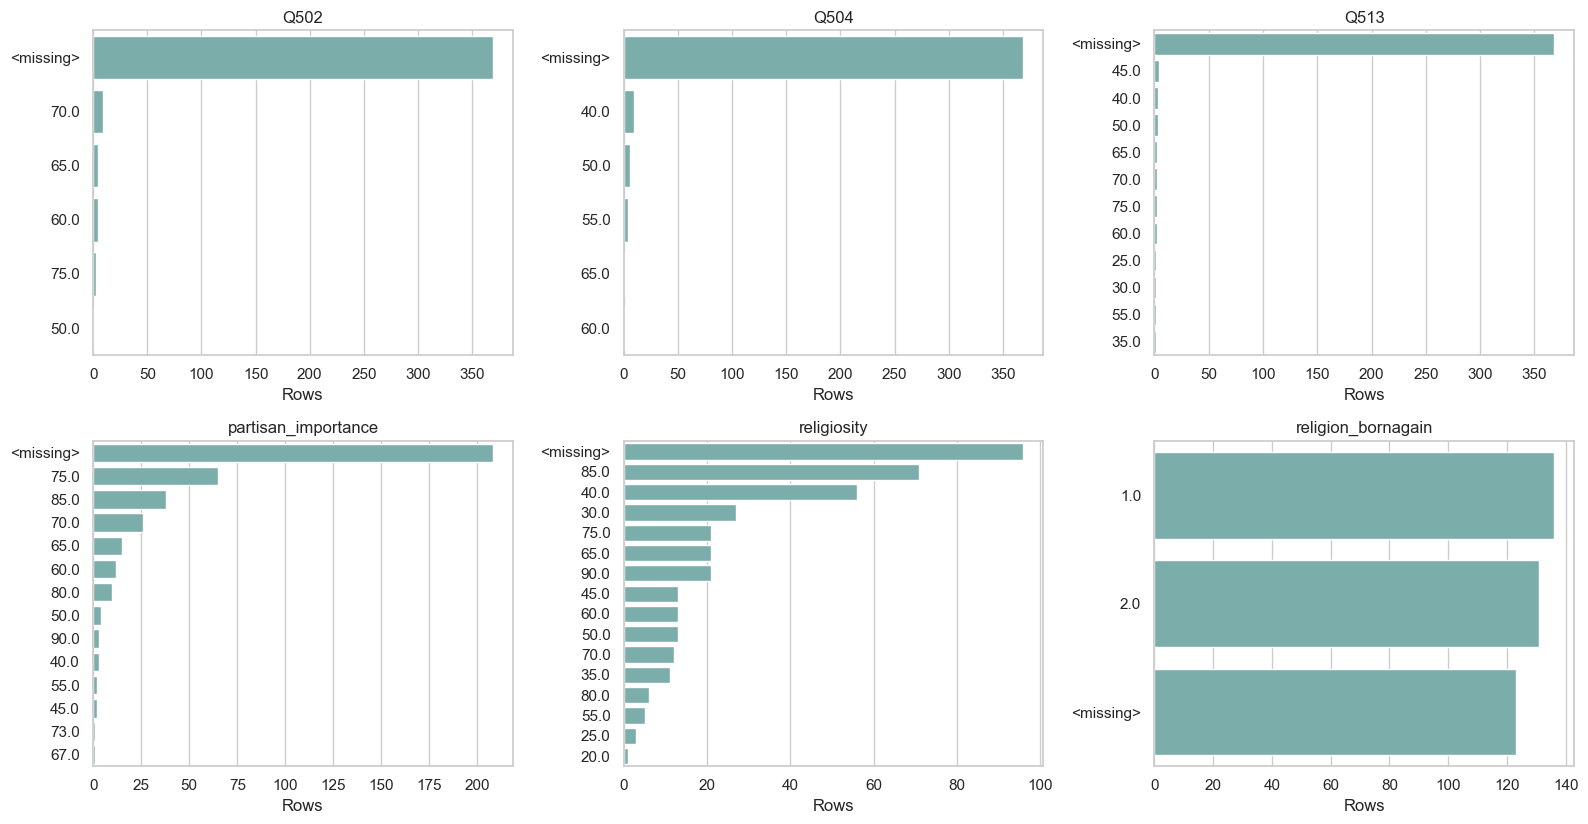

In [23]:
def plot_categorical_grid(columns: list[str], *, columns_per_page: int = 9, max_categories: int = 20) -> None:
    if not columns:
        print("No categorical/free-text response variables to plot.")
        return

    for page_start in range(0, len(columns), columns_per_page):
        page_columns = columns[page_start : page_start + columns_per_page]
        ncols = 3
        nrows = int(np.ceil(len(page_columns) / ncols))
        fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4.2 * nrows), squeeze=False)
        axes_flat = axes.ravel()

        for axis, column in zip(axes_flat, page_columns):
            counts = compiled[column].fillna("<missing>").astype(str).value_counts().head(max_categories)
            sns.barplot(x=counts.values, y=counts.index, ax=axis, color="#72B7B2")
            axis.set_xlabel("Rows")
            axis.set_ylabel("")
            axis.set_title(column)

        for axis in axes_flat[len(page_columns) :]:
            axis.set_visible(False)

        fig.tight_layout()
        figure_path = FIGURES_DIR / f"trust_categorical_response_distributions_page_{page_start // columns_per_page + 1:02d}.png"
        fig.savefig(figure_path, dpi=180, bbox_inches="tight")
        print(f"Saved {figure_path.relative_to(ROOT)}")
        plt.show()


plot_categorical_grid(categorical_response_columns)


## Distribution Summary Table

In [24]:
summary_rows = []
for column in response_columns:
    series = compiled[column]
    numeric = pd.to_numeric(series, errors="coerce")
    row = {
        "variable": column,
        "n": int(series.notna().sum()),
        "missing": int(series.isna().sum()),
        "unique": int(series.nunique(dropna=True)),
    }
    if column in numeric_response_columns:
        row.update(
            {
                "mean": float(numeric.mean()) if numeric.notna().any() else np.nan,
                "std": float(numeric.std()) if numeric.notna().sum() > 1 else np.nan,
                "min": float(numeric.min()) if numeric.notna().any() else np.nan,
                "median": float(numeric.median()) if numeric.notna().any() else np.nan,
                "max": float(numeric.max()) if numeric.notna().any() else np.nan,
                "top_value": np.nan,
                "top_count": np.nan,
            }
        )
    else:
        counts = series.fillna("<missing>").astype(str).value_counts()
        row.update(
            {
                "mean": np.nan,
                "std": np.nan,
                "min": np.nan,
                "median": np.nan,
                "max": np.nan,
                "top_value": counts.index[0] if len(counts) else np.nan,
                "top_count": int(counts.iloc[0]) if len(counts) else np.nan,
            }
        )
    summary_rows.append(row)

distribution_summary = pd.DataFrame(summary_rows)
summary_path = RESULTS_DIR / "trust_new_response_distribution_summary.csv"
distribution_summary.to_csv(summary_path, index=False)
print(f"Saved summary table to {summary_path.relative_to(ROOT)}")
display(distribution_summary)


Saved summary table to studies/trust/results/trust_new_response_distribution_summary.csv


,variable,n,missing,unique,mean,std,min,median,max,top_value,top_count
0,belief_pre,390,0,17,65.376923,20.927933,20.0,70.0,95.0,NaN,NaN
1,gender,390,0,2,1.546154,0.498505,1.0,2.0,2.0,NaN,NaN
2,year_birth,390,0,68,1977.335897,16.967608,1937.0,1977.0,2008.0,NaN,NaN
3,race,390,0,4,1.671795,1.225259,1.0,1.0,5.0,NaN,NaN
4,education,390,0,5,2.792308,1.223356,1.0,2.0,5.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
88,individual_talk,390,0,17,67.092308,15.184442,20.0,70.0,90.0,NaN,NaN
89,individual_donate,390,0,18,52.379487,18.070544,5.0,55.0,85.0,NaN,NaN
90,partisan_importance,182,208,13,NaN,NaN,NaN,NaN,NaN,<missing>,208.0
91,religiosity,294,96,15,NaN,NaN,NaN,NaN,NaN,<missing>,96.0
